<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import pandas as pd

iris = load_iris()
X = iris.data 
y = iris.target 

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

print(f"Total de amostras: {X.shape[0]}")
print(f"Amostras de treino: {X_train.shape[0]}")
print(f"Amostras de teste: {X_test.shape[0]}")

print("\nProporção original das classes:")
print(pd.Series(y).value_counts(normalize=True))

print("\nProporção das classes no conjunto de teste:")
print(pd.Series(y_test).value_counts(normalize=True))

Total de amostras: 150
Amostras de treino: 120
Amostras de teste: 30

Proporção original das classes:
0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64

Proporção das classes no conjunto de teste:
0    0.333333
2    0.333333
1    0.333333
Name: proportion, dtype: float64


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [2]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier(random_state=42)

clf.fit(X_train, y_train)

y_train_pred = clf.predict(X_train)
y_test_pred = clf.predict(X_test)

acuracia_treino = accuracy_score(y_train, y_train_pred)
acuracia_teste = accuracy_score(y_test, y_test_pred)

print(f"Acurácia no Treino: {acuracia_treino:.4f} ({acuracia_treino * 100:.2f}%)")
print(f"Acurácia no Teste:  {acuracia_teste:.4f} ({acuracia_teste * 100:.2f}%)")

Acurácia no Treino: 1.0000 (100.00%)
Acurácia no Teste:  0.9333 (93.33%)


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

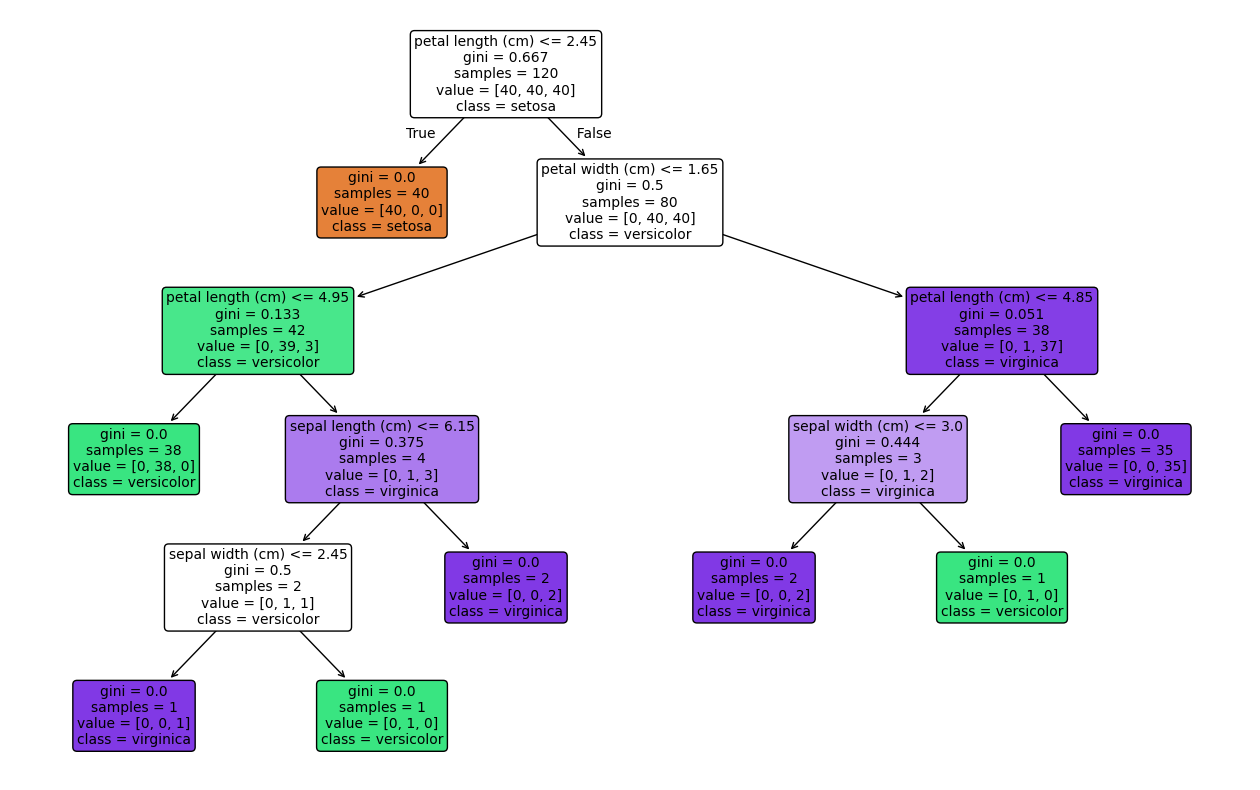

Profundidade máxima da árvore: 5


In [3]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 10))

plot_tree(
    clf, 
    feature_names=iris.feature_names, 
    class_names=iris.target_names, 
    filled=True,   
    rounded=True,  
    fontsize=10
)

plt.show()

print(f"Profundidade máxima da árvore: {clf.tree_.max_depth}")

**Adicione seu texto de solução aqui**:

1. o atributo que aparece na raiz é: petal length (cm)
2. a profundidade da arvore é 5

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [4]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

profundidades = [1, 2, 3, 4, 5, 6, 7, 8, 9, None]

resultados = []

for depth in profundidades:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    
    clf.fit(X_train, y_train)
    
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)
    
    acc_treino = accuracy_score(y_train, y_train_pred)
    acc_teste = accuracy_score(y_test, y_test_pred)
    profundidade_real = clf.tree_.max_depth
    num_folhas = clf.tree_.n_leaves
    
    resultados.append({
        'max_depth (Hiperparâmetro)': 'None' if depth is None else depth,
        'Acurácia no Treino': round(acc_treino, 4),
        'Acurácia no Teste': round(acc_teste, 4),
        'Profundidade Real da Árvore': profundidade_real,
        'Número de Folhas': num_folhas
    })

df_resultados = pd.DataFrame(resultados)

print(df_resultados.to_string(index=False))

max_depth (Hiperparâmetro)  Acurácia no Treino  Acurácia no Teste  Profundidade Real da Árvore  Número de Folhas
                         1              0.6667             0.6667                            1                 2
                         2              0.9667             0.9333                            2                 3
                         3              0.9833             0.9667                            3                 5
                         4              0.9917             0.9333                            4                 7
                         5              1.0000             0.9333                            5                 8
                         6              1.0000             0.9333                            5                 8
                         7              1.0000             0.9333                            5                 8
                         8              1.0000             0.9333                            5  

**Em qual profundidade começa o overfitting?**
**Por que a árvore consegue 100% no treino quando max_depth=None?**

1. o overfitting começa na profundidade 5, porque a partir dai TODAS tem acuracia de 100% e mesma profundidade real, mostrando que o modelo está muito super ajustados aos dados.

# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [5]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

criterios = ["gini", "entropy"]

resultados_criterio = []

for crit in criterios:
    clf_crit = DecisionTreeClassifier(criterion=crit, random_state=42)
    
    clf_crit.fit(X_train, y_train)
    
    y_train_pred = clf_crit.predict(X_train)
    y_test_pred = clf_crit.predict(X_test)
    
    acc_treino = accuracy_score(y_train, y_train_pred)
    acc_teste = accuracy_score(y_test, y_test_pred)
    profundidade = clf_crit.tree_.max_depth
    
    resultados_criterio.append({
        'Critério': crit,
        'Acurácia no Treino': round(acc_treino, 2),
        'Acurácia no Teste': round(acc_teste, 2),
        'Profundidade da Árvore': profundidade
    })

df_criterio = pd.DataFrame(resultados_criterio)
print(df_criterio.to_string(index=False))

Critério  Acurácia no Treino  Acurácia no Teste  Profundidade da Árvore
    gini                 1.0               0.93                       5
 entropy                 1.0               0.93                       5


- para o datased, com os parametros setados o modelo encntrou a mesma acuracia para ambos os criteiros, mostrando que nesse caso ela independe dele, dependendo mais dos demais hiperparametros

# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

In [9]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()
X = iris.data 
y = iris.target 

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

max_depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, None]
min_samples_splits = [2, 5, 10]
min_samples_leafs = [1, 2, 4]
criterios = ["gini", "entropy"]

resultados = []

for crit in criterios:
    for depth in max_depths:
        for min_split in min_samples_splits:
            for min_leaf in min_samples_leafs:
                
                clf = DecisionTreeClassifier(
                    criterion=crit,
                    max_depth=depth,
                    min_samples_split=min_split,
                    min_samples_leaf=min_leaf,
                    random_state=42
                )
                
                clf.fit(X_train, y_train)
                
                y_train_pred = clf.predict(X_train)
                y_test_pred = clf.predict(X_test)
                
                acc_treino = accuracy_score(y_train, y_train_pred)
                acc_teste = accuracy_score(y_test, y_test_pred)
                
                resultados.append({
                    'criterion': crit,
                    'max_depth': 'None' if depth is None else depth,
                    'min_samples_split': min_split,
                    'min_samples_leaf': min_leaf,
                    'acuracia_treino': round(acc_treino, 4),
                    'acuracia_teste': round(acc_teste, 4)
                })

df_resultados = pd.DataFrame(resultados)

print("Top 10 modelos encontrados:")
df_resultados.sort_values(by='acuracia_teste', ascending=False).head(20)

Top 10 modelos encontrados:


,criterion,max_depth,min_samples_split,min_samples_leaf,acuracia_treino,acuracia_teste
18,gini,3,2,1,0.9833,0.9667
19,gini,3,2,2,0.9833,0.9667
51,gini,6,10,1,0.9833,0.9667
50,gini,6,5,4,0.9833,0.9667
39,gini,5,5,1,0.9833,0.9667
38,gini,5,2,4,0.9833,0.9667
33,gini,4,10,1,0.9833,0.9667
35,gini,4,10,4,0.9833,0.9667
32,gini,4,5,4,0.9833,0.9667
31,gini,4,5,2,0.9833,0.9667
